In [103]:
import pandas as pd
import sys

sys.path.append('../')
from data.dicts.col_dict import *
from helpers.plots import *
plt.rcParams.update(rc)

In [104]:
res_dir = '../results/imputed_sh/'
data_dir = 'tables'

results = pd.read_csv(f'{res_dir}{data_dir}/metrics.csv')
results.query('model == "_xgboost"').head()

,model,race_adj,race,mae,mse,r2,n,mae_mean_bs,mae_ci_lower,mae_ci_upper,mse_mean_bs,mse_ci_lower,mse_ci_upper,r2_mean_bs,r2_ci_lower,r2_ci_upper
10,_xgboost,False,All,1.750414,5.085617,0.969518,7854,1.750525,1.717040,1.783169,5.081043,4.859167,5.315222,0.969525,0.967866,0.971103
11,_xgboost,False,Non-Hispanic white,1.675178,4.689557,0.972200,5120,1.675375,1.639043,1.713740,4.693817,4.410359,5.031622,0.972166,0.969863,0.974151
12,_xgboost,False,Non-Hispanic black,1.914175,5.933833,0.963138,2443,1.913986,1.852769,1.974936,5.936561,5.522587,6.368885,0.963053,0.959524,0.966289
13,_xgboost,False,Mexican American,1.703616,4.954987,0.969841,289,1.705025,1.550167,1.868101,4.964745,4.070632,5.933530,0.969423,0.962074,0.975507
14,_xgboost,False,Other,1.080326,1.779481,0.894142,2,1.067023,0.297781,1.862871,1.750737,0.088674,3.470288,0.460483,0.000000,0.894142


/tmp/ipykernel_1223314/2835827776.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=1.0)


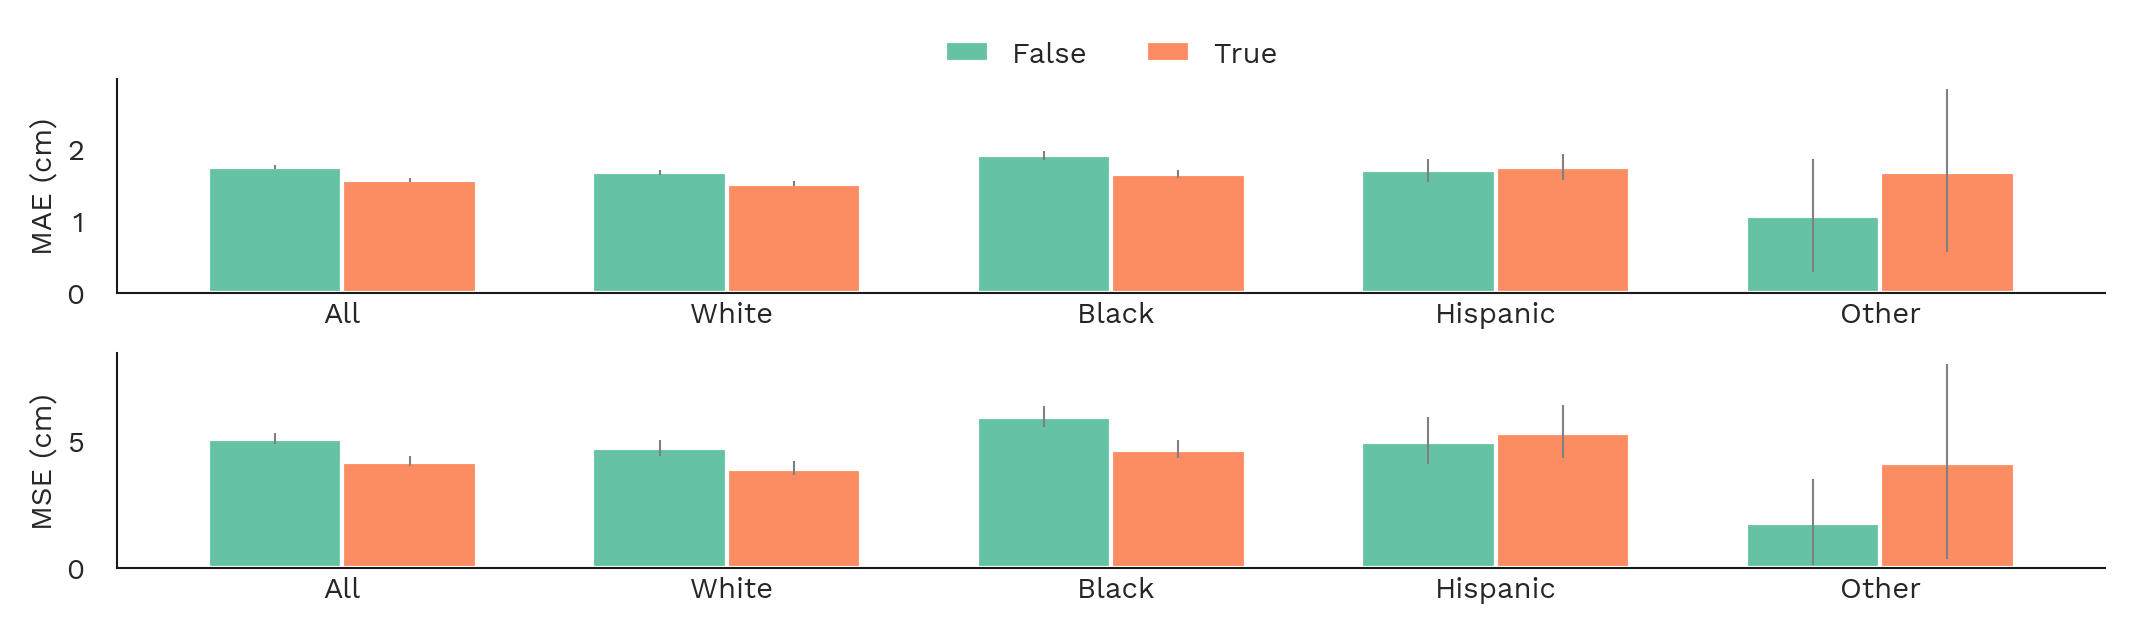

In [116]:
# Plotting

def plot_metrics_subplots(results, metrics, model):
    df = results.query(f'model == "{model}"').copy()
    df['race'] = df['race'].str.replace('Non-Hispanic', '')
    df['race'] = df['race'].str.replace('Mexican American', 'Hispanic').str.title()
    races = df['race'].unique()
    race_adjs = df['race_adj'].unique()
    bar_width = 0.35
    x = np.arange(len(races))
    
    n_metrics = len(metrics)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(7, 1*n_metrics), dpi=300, squeeze=False)
    axes = axes[:, 0]  # Unpack the column from shape (n_metrics, 1)
    
    for j, metric in enumerate(metrics):
        ax = axes[j]
        n_bars = len(race_adjs)
        total_width = bar_width * n_bars
        offsets = [(-total_width/2) + bar_width*i + bar_width/2 for i in range(n_bars)]
    
        for idx, race_adj in enumerate(race_adjs):
            values = []
            ci_lower = []
            ci_upper = []
            for race in races:
                row = df[(df['race'] == race) & (df['race_adj'] == race_adj)]
                values.append(float(row[f'{metric}_mean_bs'].values[0]))
                ci_lower.append(float(values[-1] - row[f'{metric}_ci_lower'].values[0]))
                ci_upper.append(float(row[f'{metric}_ci_upper'].values[0]) - values[-1])
            bar_positions = x + offsets[idx]
            ax.bar(bar_positions, values, bar_width, label=str(race_adj))
            ax.errorbar(bar_positions, values, yerr=[ci_lower, ci_upper], fmt='none', linewidth=0.5, capsize=0, color='gray')
            
        ax.set_xticks(x)
        ax.set_xticklabels(races)
        ax.set_xlabel('')
        ax.set_ylabel(metric.upper() + ' (cm)')
        if j == 0:  # Only plot legend on first subplot (now, first row)
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    
    plt.savefig(f'{res_dir}/figures/metrics_{model}.pdf', dpi=300)
    plt.savefig(f'../figures/metrics_{model}.pdf', dpi=300)
    plt.tight_layout(pad=1.0)
    plt.show()

plot_metrics_subplots(results, ['mae','mse'], '_xgboost')

,seqn,RIDRETH,imputed_value,model,race_adj
0,B-41475,3,212.618907,_linreg,False
1,B-41477,4,230.131628,_linreg,False
2,B-41479,2,211.981176,_linreg,False
3,B-41481,1,249.387312,_linreg,False
4,B-41482,2,236.376336,_linreg,False


/tmp/ipykernel_1223314/1134274335.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preds['RIDRETH'] = (
/home/aas926/miniconda3/envs/xray_env/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/aas926/miniconda3/envs/xray_env/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

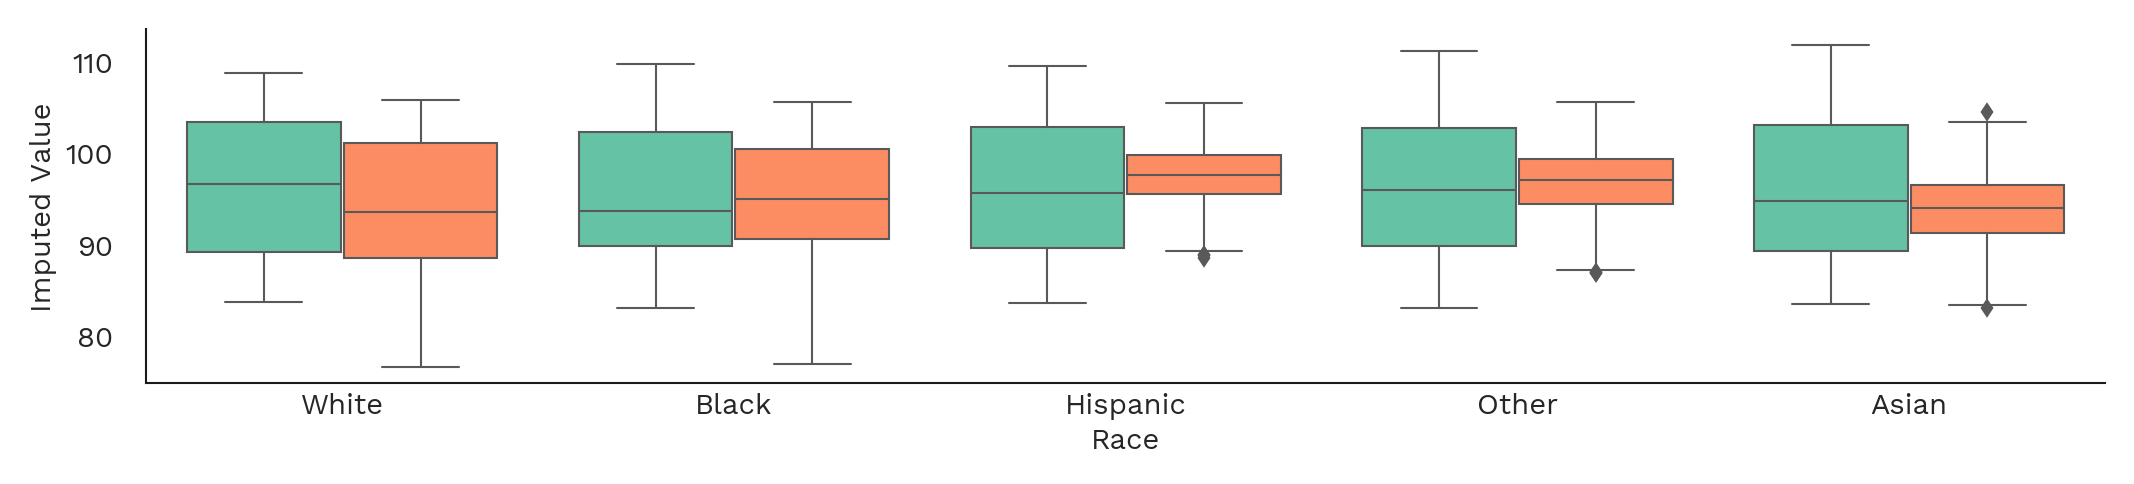

In [117]:
preds = pd.read_csv(f'{res_dir}{data_dir}/imputed_results.csv')
display(preds.head())

def boxplot_preds(preds, model):
    import matplotlib as mpl
    # Define the order and mapping for races you want
    race_order = ['White', 'Black', 'Hispanic', 'Other', 'Asian']
    race_label_map = {
        'white': 'White',
        'black': 'Black',
        'hispanic': 'Hispanic',
        'mexican american': 'Hispanic',
        'other': 'Other',
        'asian': 'Asian',
        'south asian': 'Asian'
    }
    preds = preds.query(f'model == "{model}"')
    # Convert codes to string and lower for mapping, then apply label map
    preds['RIDRETH'] = (
        preds['RIDRETH'].astype(str)
        .map(int_race_dict)
        .str.lower()
        .map(race_label_map)
    )

    # Filter to only races in the order (removes NaNs and anything unexpected)
    df = preds[preds['RIDRETH'].isin(race_order) & (preds['model'] == model)].copy()
    df['RIDRETH'] = pd.Categorical(df['RIDRETH'], categories=race_order, ordered=True)

    plt.figure(figsize=(7, 1.5), dpi=300)
    ax = sns.boxplot(
        data=df,
        x='RIDRETH',
        y='imputed_value',
        hue='race_adj',
        linewidth=0.5,            
        fliersize=2,               
        saturation=1
    )
    
    # Reduce median and whisker line widths for Nature style appearance
    for artist in ax.artists:
        artist.set_linewidth(0.5)
    for line in ax.lines:
        line.set_linewidth(0.5)

    ax.set_xlabel("Race")
    ax.set_ylabel("Imputed Value")
    ax.get_legend().remove()
    ax.tick_params(axis='both', which='major')
    plt.tight_layout(pad=1.0)
    plt.savefig(f'{res_dir}/figures/dist_{model}.pdf', dpi=300)
    plt.savefig(f'../figures/dist_{model}.pdf', dpi=300)
    plt.show()
    
boxplot_preds(preds, '_xgboost')
